In [14]:
%run db.ipynb

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [20]:
conn = get_connection()
df = pd.read_sql("SELECT * FROM restaurants;", conn)
conn.close()
print(df.head())

     id   restaurant_name restaurant_type  rate_out_of_5  num_of_ratings  \
0  1024       FeelTheROLL     Quick Bites            3.4               7   
1  1025         L-81 Cafe     Quick Bites            3.9              48   
2  1026            refuel            Cafe            3.7              37   
3  1027   Biryani Central   Casual Dining            2.7             135   
4  1028           The Bbq   Casual Dining            2.8              40   

   avg_cost_two_people online_order table_booking  
0                  200           No          No\r  
1                  400          Yes          No\r  
2                  400          Yes          No\r  
3                  550          Yes          No\r  
4                  700          Yes          No\r  


C:\Users\anmol\AppData\Local\Temp\ipykernel_26992\4011127409.py:2: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql("SELECT * FROM restaurants;", conn)


# Data Cleaning and Preparation

In [21]:
def handleRate(value):
    value=str(value).split('/')
    value=value[0];
    return float(value)
df['rate_out_of_5']=df['rate_out_of_5'].apply(handleRate)
print(df.head())

     id   restaurant_name restaurant_type  rate_out_of_5  num_of_ratings  \
0  1024       FeelTheROLL     Quick Bites            3.4               7   
1  1025         L-81 Cafe     Quick Bites            3.9              48   
2  1026            refuel            Cafe            3.7              37   
3  1027   Biryani Central   Casual Dining            2.7             135   
4  1028           The Bbq   Casual Dining            2.8              40   

   avg_cost_two_people online_order table_booking  
0                  200           No          No\r  
1                  400          Yes          No\r  
2                  400          Yes          No\r  
3                  550          Yes          No\r  
4                  700          Yes          No\r  


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7105 entries, 0 to 7104
Data columns (total 8 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   id                   7105 non-null   int64  
 1   restaurant_name      7105 non-null   object 
 2   restaurant_type      7105 non-null   object 
 3   rate_out_of_5        7105 non-null   float64
 4   num_of_ratings       7105 non-null   int64  
 5   avg_cost_two_people  7105 non-null   int64  
 6   online_order         7105 non-null   object 
 7   table_booking        7105 non-null   object 
dtypes: float64(1), int64(3), object(4)
memory usage: 444.2+ KB


In [8]:
print(df.isnull().sum())

id                     0
restaurant_name        0
restaurant_type        0
rate_out_of_5          0
num_of_ratings         0
avg_cost_two_people    0
online_order           0
table_booking          0
dtype: int64


# Popular Restaurant Categories

In [22]:
top_types = df['restaurant_type'].value_counts().nlargest(5).index

Text(0.5, 0, 'Type of restaurant')

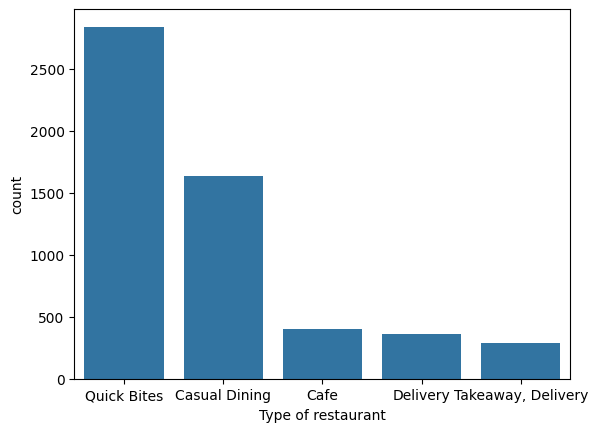

In [23]:
sns.countplot(x = df['restaurant_type'], order=top_types)
plt.xlabel("Type of restaurant")

# Number of Ratings by Restaurant Type

Text(0, 0.5, 'Number of Ratings')

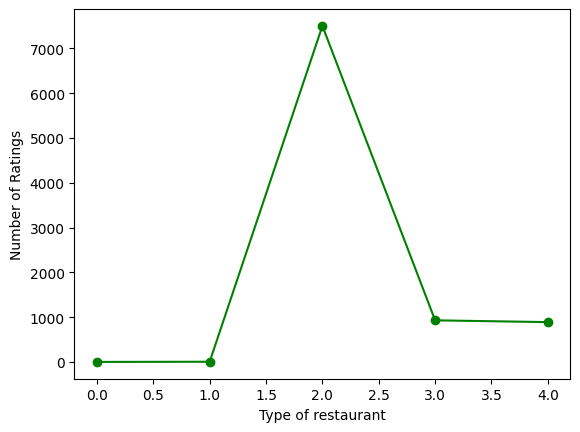

In [24]:
grouped_data = df.groupby('restaurant_type')['num_of_ratings'].sum().value_counts().nlargest(5).index
result = pd.DataFrame({'num_of_ratings': grouped_data})
plt.plot(result, c='green', marker='o')
plt.xlabel('Type of restaurant')
plt.ylabel('Number of Ratings')

# The Most Rated Restaurant

In [25]:
max_no_ratings = df['num_of_ratings'].max()
restaurant_with_max_ratings = df.loc[df['num_of_ratings'] == max_no_ratings, 'restaurant_name']

print('Restaurant(s) with the maximum number of ratings:')
print(restaurant_with_max_ratings)

Restaurant(s) with the maximum number of ratings:
1035    Byg Brewski Brewing Company
Name: restaurant_name, dtype: object


# Online Order Availability

In [26]:
order_counts = df['online_order'].value_counts()


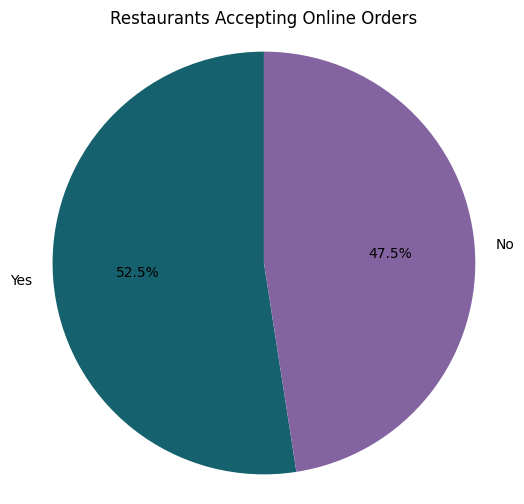

In [27]:
plt.figure(figsize=(6, 6))
plt.pie(order_counts, labels=order_counts.index, autopct='%1.1f%%', startangle=90, colors= ['#15616d', '#8464a0'])
plt.title("Restaurants Accepting Online Orders")
plt.axis('equal') 
plt.show()


# Analyze Ratings

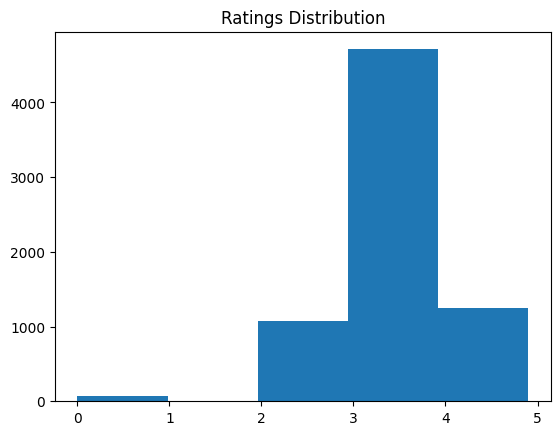

In [39]:
plt.hist(df['rate_out_of_5'],bins=5)
plt.title('Ratings Distribution')
plt.show()

# Approximate Cost for Two People

In [29]:
top_costing = df['avg_cost_two_people'].value_counts().nlargest(15).index

<Axes: xlabel='avg_cost_two_people', ylabel='count'>

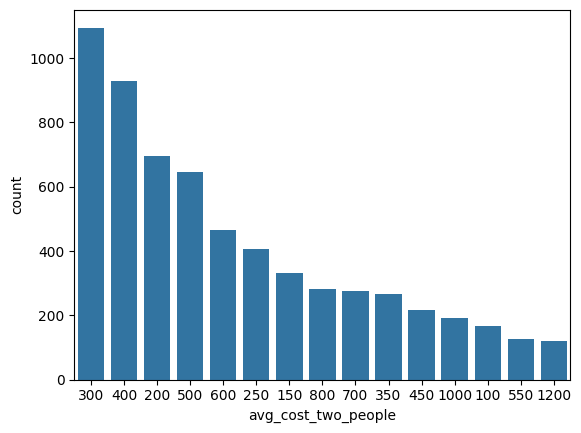

In [30]:
couple_data=df['avg_cost_two_people']
sns.countplot(x=couple_data, order= top_costing)

# Online vs Offline Orders - Rating Comparison

In [31]:
palette = {'Yes': '#4CAF50', 'No': '#F44336'}

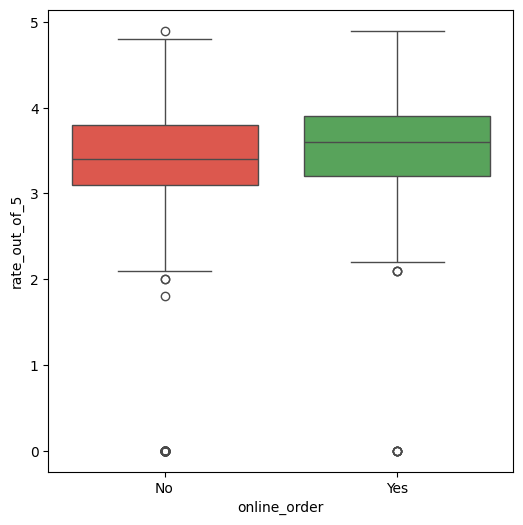

In [32]:
plt.figure(figsize = (6,6))
sns.boxplot(x = 'online_order', y = 'rate_out_of_5', hue='online_order', data = df, palette = palette, dodge=False)
plt.legend([], [], frameon=False)

# Order Mode Preferences by Restaurant Type

In [33]:
top_10_types = df['restaurant_type'].value_counts().nlargest(10).index

In [34]:
filtered_df = df[df['restaurant_type'].isin(top_10_types)]

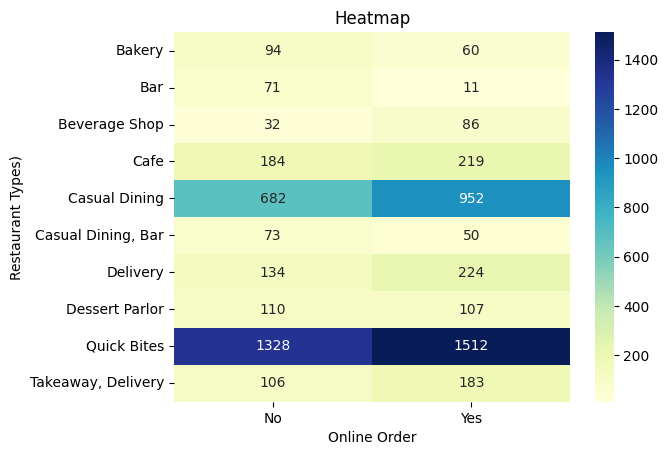

In [35]:
pivot_table = filtered_df.pivot_table(index='restaurant_type', columns='online_order', aggfunc='size', fill_value=0)
sns.heatmap(pivot_table, annot=True, cmap='YlGnBu', fmt='d')
plt.title('Heatmap')
plt.xlabel('Online Order')
plt.ylabel('Restaurant Types)')
plt.show()

#                                                     Thank You